# Free-Vibration (Modal) Analysis

`BeamAnalysis.modal()` returns the natural frequencies and mode shapes of a beam. It assembles a **consistent mass matrix** alongside the stiffness matrix and solves the generalized eigenproblem

$$ \mathbf{K}\,\boldsymbol\phi = \omega^2\,\mathbf{M}\,\boldsymbol\phi, $$

refining each span into `nseg` Euler–Bernoulli sub-elements so the higher modes are captured accurately. Supply the **mass per unit length** (in units consistent with `EI`); supports — including elastic springs — are taken from the beam, and the analysis is independent of any applied loads.

The result is a `ModalResults` carrying the frequencies (`omega` rad/s, `f` Hz, `periods` s) and the mode shapes, drawn with **`plot_results()`** (the beam schematic above the mode shapes) or **`plot_modes()`** (mode shapes only).

Supported for prismatic, fixed-fixed members without shear flexibility (`GAv`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycba as cba

## Example 1 - Simply-supported beam

For a prismatic simply-supported beam the natural circular frequencies are the standard textbook result

$$ \omega_n = \left(\frac{n\pi}{L}\right)^2 \sqrt{\frac{EI}{\bar m}}. $$

We first evaluate this **analytically**, then obtain the same frequencies from PyCBA — keeping the two separate.

In [2]:
# Theory: the analytic natural frequencies
L, EI, mbar = 10.0, 1.0, 1.0          # length, EI, mass/length (consistent units)

n = np.arange(1, 5)
omega_exact = (n * np.pi / L) ** 2 * np.sqrt(EI / mbar)
f_exact = omega_exact / (2 * np.pi)
f_exact

array([0.01570796, 0.06283185, 0.14137167, 0.25132741])

Now solely the PyCBA usage — build the beam, supply the mass, and call `modal()`. `plot_results()` shows the mode shapes against the beam schematic:

ModalResults(4 modes; f [Hz] = 0.01571, 0.06284, 0.1414, 0.2515)


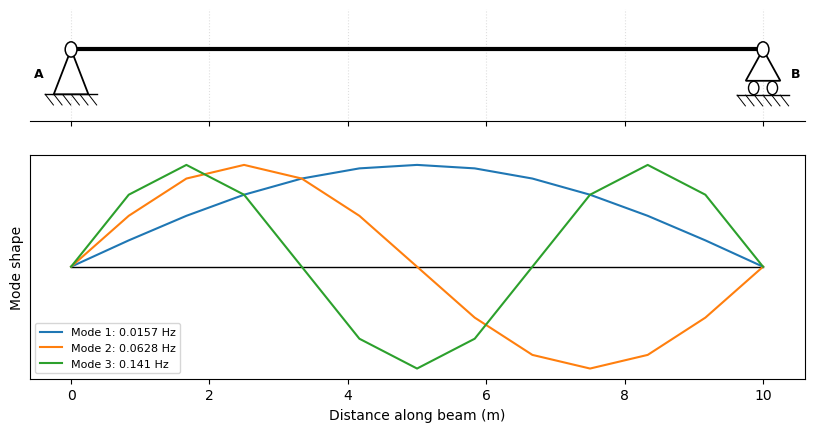

In [3]:
# PyCBA: build the beam, run the modal analysis
modal = cba.BeamAnalysis([L], EI, [-1, 0, -1, 0]).modal(mass=mbar, n_modes=4)
print(modal)

modal.plot_results();

The computed frequencies match the analytic values closely:

In [4]:
pd.DataFrame(
    {"PyCBA f (Hz)": modal.f, "exact f (Hz)": f_exact},
    index=[f"mode {i}" for i in n],
).round(5)

,PyCBA f (Hz),exact f (Hz)
mode 1,0.01571,0.01571
mode 2,0.06284,0.06283
mode 3,0.14141,0.14137
mode 4,0.25153,0.25133


## Example 2 - Two-span continuous bridge

A two-span continuous bridge in SI units (N, m, kg). `modal()` returns `omega` (rad/s), `f` (Hz) and the natural `periods` (s); `plot_results()` shows the mode shapes against the bridge schematic — note the symmetric / antisymmetric pairs typical of a two-span deck.

mode 1:  f =  1.113 Hz   (T = 0.899 s)
mode 2:  f =  1.738 Hz   (T = 0.575 s)
mode 3:  f =  4.451 Hz   (T = 0.225 s)
mode 4:  f =  5.633 Hz   (T = 0.178 s)


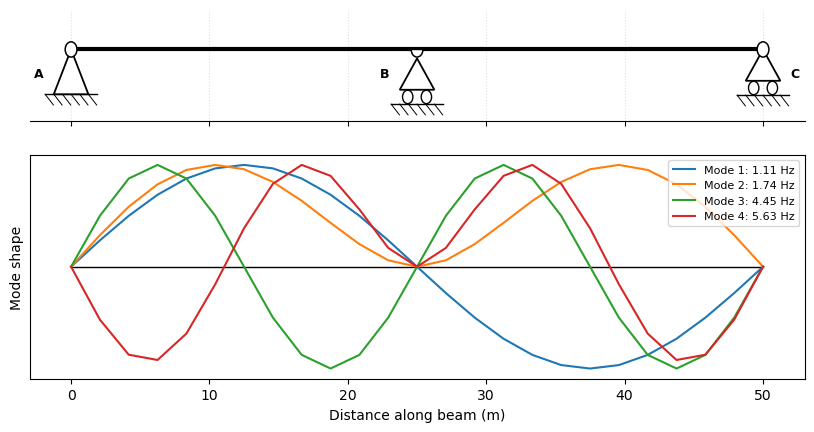

In [5]:
E, I = 2.1e11, 1.4e-3          # Pa, m^4 (steel girder)
mbar_b = 1500.0                # kg/m (girder + deck)

bridge = cba.BeamAnalysis([25.0, 25.0], E * I, [-1, 0, -1, 0, -1, 0])
modal_b = bridge.modal(mass=mbar_b, n_modes=4)
for i in range(modal_b.n_modes):
    print(f"mode {i+1}:  f = {modal_b.f[i]:6.3f} Hz   (T = {modal_b.periods[i]:.3f} s)")

modal_b.plot_results(modes=[0, 1, 2, 3]);

## Example 3 - Mesh density (`nseg`)

Each span is internally meshed into `nseg` Euler–Bernoulli sub-elements (default 12); one element per span would resolve only the first mode or two. The higher the mode, the finer the mesh it needs. Pass `nseg=` to control it — here we watch the **4th** mode of the simply-supported beam of Example 1 converge to its analytic value as `nseg` increases (the consistent mass matrix approaches from above):

In [6]:
mode = 4
f4_exact = (mode * np.pi / L) ** 2 * np.sqrt(EI / mbar) / (2 * np.pi)

rows = []
for nseg in (2, 4, 8, 16, 32):
    f4 = cba.BeamAnalysis([L], EI, [-1, 0, -1, 0]).modal(mass=mbar, n_modes=4, nseg=nseg).f[3]
    rows.append((nseg, f4, 100 * (f4 / f4_exact - 1)))

df = pd.DataFrame(rows, columns=["nseg", "f4 (Hz)", "error (%)"]).set_index("nseg")
print(f"analytic f4 = {f4_exact:.5f} Hz")
df.round({"f4 (Hz)": 5, "error (%)": 2})

analytic f4 = 0.25133 Hz


,f4 (Hz),error (%)
nseg,,
2,0.31958,27.16
4,0.27895,10.99
8,0.25232,0.39
16,0.25139,0.03
32,0.25133,0.00


## Notes

- The mass is a mass per unit length, in units consistent with `EI` (e.g. kg/m with `EI` in N·m², giving frequencies in Hz).
- `nseg` (default 12) sets the sub-elements per span; the first several modes are already well within 1% with the default, while higher modes need a finer mesh (Example 3).
- `plot_results()` draws the beam schematic above the mode shapes; `plot_modes()` draws the mode shapes alone — both accept a `modes=` list and a `units=` argument.
- Supported for prismatic, fixed-fixed members without shear flexibility (`GAv`); elastic spring supports are included. Other combinations raise a clear `NotImplementedError`.